# JSBSim C172 do_trim Only Grid v45

This notebook only tests whether JSBSim `fdm.do_trim(0)` succeeds under different initial longitudinal conditions. It does not run empirical hold validation, PINN, PID, or MPC. A `TrimFailureError` is treated as a result row, not as a notebook failure.

## 0. Install & Imports

In [1]:
!pip install jsbsim -q
print('Install complete')


Install complete


In [2]:
import os, time, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jsbsim

try:
    from google.colab import drive
    drive.mount('/content/drive')
    COLAB_DRIVE_MOUNTED = True
except Exception as exc:
    print('Drive mount skipped or unavailable:', exc)
    COLAB_DRIVE_MOUNTED = False

FPS_PER_KT = 1.687809857


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Configuration

In [3]:
EXPERIMENT_NAME = 'jsbsim_c172_dotrim_only_grid_v45'
RUN_MODE = 'dotrim_only'

INIT_ALT_FT = 3000.0
INIT_PITCH_GRID_DEG = np.array([-4.0, -2.0, 0.0, 2.0, 4.0])
SPEED_GRID_KTS = np.arange(70.0, 121.0, 5.0)
THROTTLE_GRID = np.round(np.arange(0.45, 1.001, 0.05), 3)
ELEVATOR_GRID = np.round(np.arange(-0.20, 0.201, 0.10), 3)
TRIM_MODE = 0  # longitudinal trim only

RESULT_ROOT = '/content/drive/MyDrive/Colab Result' if COLAB_DRIVE_MOUNTED else './Colab Result'
SAVE_DIR = os.path.join(RESULT_ROOT, 'PINN_MPC', EXPERIMENT_NAME)
os.makedirs(SAVE_DIR, exist_ok=True)

N_CASES = len(INIT_PITCH_GRID_DEG) * len(SPEED_GRID_KTS) * len(THROTTLE_GRID) * len(ELEVATOR_GRID)
print('do_trim-only grid cases:', N_CASES)
print('SAVE_DIR:', SAVE_DIR)


do_trim-only grid cases: 3300
SAVE_DIR: /content/drive/MyDrive/Colab Result/PINN_MPC/jsbsim_c172_dotrim_only_grid_v45


## 2. Minimal JSBSim Helpers

In [4]:
def get_prop(fdm, name, default=np.nan):
    try:
        return float(fdm[name])
    except Exception:
        return float(default)


def make_fdm(init_speed_kts, init_pitch_deg, init_elevator, init_throttle, init_alt_ft=INIT_ALT_FT):
    fdm = jsbsim.FGFDMExec(None, None)
    fdm.set_debug_level(0)
    fdm.load_model('c172p')
    fdm['ic/h-sl-ft'] = float(init_alt_ft)
    fdm['ic/vt-kts'] = float(init_speed_kts)
    fdm['ic/theta-deg'] = float(init_pitch_deg)
    fdm['ic/psi-true-deg'] = 0.0
    fdm.run_ic()
    fdm['propulsion/engine/set-running'] = 1
    fdm['fcs/elevator-cmd-norm'] = float(init_elevator)
    fdm['fcs/throttle-cmd-norm'] = float(init_throttle)
    return fdm


def read_trim_state(fdm):
    vt_fps = get_prop(fdm, 'velocities/vt-fps')
    return {
        'trim_alt_ft': get_prop(fdm, 'position/h-sl-ft'),
        'trim_speed_kts': vt_fps / FPS_PER_KT if np.isfinite(vt_fps) else np.nan,
        'trim_theta_deg': np.degrees(get_prop(fdm, 'attitude/theta-rad')),
        'trim_q_deg_s': np.degrees(get_prop(fdm, 'velocities/q-rad_sec')),
        'trim_alpha_deg': np.degrees(get_prop(fdm, 'aero/alpha-rad', np.nan)),
        'trim_elevator': get_prop(fdm, 'fcs/elevator-cmd-norm'),
        'trim_throttle': get_prop(fdm, 'fcs/throttle-cmd-norm'),
    }


## 3. do_trim For-Loop Grid

In [5]:
def run_one_dotrim_case(init_speed_kts, init_pitch_deg, init_elevator, init_throttle):
    row = {
        'trim_mode': TRIM_MODE,
        'seed_speed_kts': float(init_speed_kts),
        'seed_pitch_deg': float(init_pitch_deg),
        'seed_elevator': float(init_elevator),
        'seed_throttle': float(init_throttle),
        'success': False,
        'status': 'not_run',
        'exception_type': '',
        'exception_message': '',
    }
    try:
        fdm = make_fdm(init_speed_kts, init_pitch_deg, init_elevator, init_throttle)
        result = fdm.do_trim(int(TRIM_MODE))
        row['success'] = True
        row['status'] = f'returned:{result}'
        row.update(read_trim_state(fdm))
    except Exception as exc:
        row['success'] = False
        row['status'] = 'failed'
        row['exception_type'] = type(exc).__name__
        row['exception_message'] = str(exc)
        # Keep NaNs for trim outputs on failure.
        row.update({
            'trim_alt_ft': np.nan,
            'trim_speed_kts': np.nan,
            'trim_theta_deg': np.nan,
            'trim_q_deg_s': np.nan,
            'trim_alpha_deg': np.nan,
            'trim_elevator': np.nan,
            'trim_throttle': np.nan,
        })
    return row

rows = []
t0 = time.time()
idx = 0
for pitch_deg in INIT_PITCH_GRID_DEG:
    for speed_kts in SPEED_GRID_KTS:
        for elevator in ELEVATOR_GRID:
            for throttle in THROTTLE_GRID:
                idx += 1
                rows.append(run_one_dotrim_case(speed_kts, pitch_deg, elevator, throttle))
                if idx % 100 == 0:
                    df_tmp = pd.DataFrame(rows)
                    print(f'{idx}/{N_CASES} elapsed={time.time()-t0:.1f}s success={int(df_tmp.success.sum())}')

dotrim_df = pd.DataFrame(rows)
print('Finished do_trim-only grid.')
print('Success count:', int(dotrim_df['success'].sum()), '/', len(dotrim_df))
display(dotrim_df['success'].value_counts(dropna=False).to_frame('count'))

if dotrim_df['success'].any():
    print('Successful trim cases:')
    display(dotrim_df[dotrim_df['success']].head(50))
else:
    print('No successful do_trim cases in this grid.')
    print('Failure types:')
    display(dotrim_df.groupby(['exception_type', 'exception_message']).size().reset_index(name='count').sort_values('count', ascending=False).head(20))




     JSBSim Flight Dynamics Model v1.3.0 Apr  9 2026 10:00:08
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

  Sorry, udot doesn't appear to be trimmable
  Sorry, udot doesn't appear to be trimmable
  Sorry, udot doesn't appear to be trimmable
  Sorry, udot doesn't appear to be trimmable
  Sorry, udot doesn't appear to be trimmable
  Sorry, udot doesn't appear to be trimmable
  Sorry, udot doesn't appear to be trimmable
  Sorry, udot doesn't appear to be trimmable
  Sorry, udot doesn't appear to be trimmable
  Sorry, udot doesn't appear to be trimmable
  Sorry, udot doesn't appear to be trimmable
  Sorry, udot doesn't appear to be trimmable
  Sorry, udot doesn't appear to be trimmable
  Sorry, udot doesn't appear to be trimmable
  Sorry, udot doesn't appear to be trimmable
  Sorry, udot doesn't appear to be trimmable
  Sorry, udot doesn't appear to be trimmable
  Sorry, udot doesn't appear to be trimmable
  Sorry, udot doesn't appear to be trimmable
  Sorry, udot doesn't

,count
success,
False,3300


No successful do_trim cases in this grid.
Failure types:


,exception_type,exception_message,count
0,TrimFailureError,Trim Failed,3300


## 4. Save and Quick Diagnostics

Saved: /content/drive/MyDrive/Colab Result/PINN_MPC/jsbsim_c172_dotrim_only_grid_v45/jsbsim_c172_dotrim_only_grid_v45_dotrim_only.csv
Saved summary: /content/drive/MyDrive/Colab Result/PINN_MPC/jsbsim_c172_dotrim_only_grid_v45/jsbsim_c172_dotrim_only_summary_v45_dotrim_only.csv


,success,exception_type,exception_message,count
0,False,TrimFailureError,Trim Failed,3300


Saved plot: /content/drive/MyDrive/Colab Result/PINN_MPC/jsbsim_c172_dotrim_only_grid_v45/jsbsim_c172_dotrim_only_success_v45_dotrim_only.png


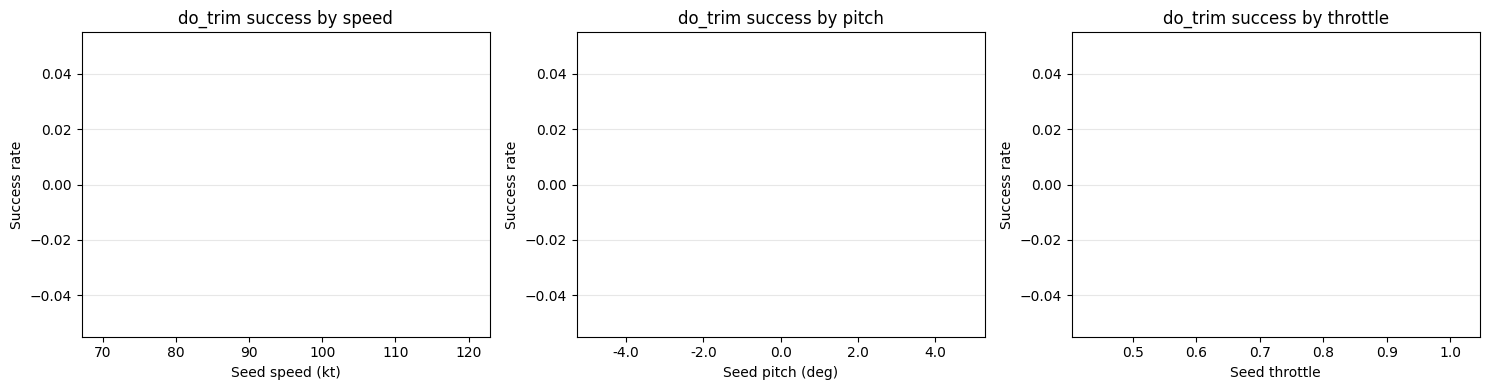

In [6]:
csv_path = os.path.join(SAVE_DIR, f'jsbsim_c172_dotrim_only_grid_v45_{RUN_MODE}.csv')
dotrim_df.to_csv(csv_path, index=False)
print('Saved:', csv_path)

summary = dotrim_df.groupby(['success', 'exception_type', 'exception_message'], dropna=False).size().reset_index(name='count')
summary_path = os.path.join(SAVE_DIR, f'jsbsim_c172_dotrim_only_summary_v45_{RUN_MODE}.csv')
summary.to_csv(summary_path, index=False)
print('Saved summary:', summary_path)
display(summary)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# Success by speed.
speed_success = dotrim_df.groupby('seed_speed_kts')['success'].mean()
axes[0].bar(speed_success.index, speed_success.values)
axes[0].set_xlabel('Seed speed (kt)')
axes[0].set_ylabel('Success rate')
axes[0].set_title('do_trim success by speed')
# Success by pitch.
pitch_success = dotrim_df.groupby('seed_pitch_deg')['success'].mean()
axes[1].bar(pitch_success.index.astype(str), pitch_success.values)
axes[1].set_xlabel('Seed pitch (deg)')
axes[1].set_ylabel('Success rate')
axes[1].set_title('do_trim success by pitch')
# Success by throttle.
thr_success = dotrim_df.groupby('seed_throttle')['success'].mean()
axes[2].bar(thr_success.index, thr_success.values, width=0.035)
axes[2].set_xlabel('Seed throttle')
axes[2].set_ylabel('Success rate')
axes[2].set_title('do_trim success by throttle')
for ax in axes:
    ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plot_path = os.path.join(SAVE_DIR, f'jsbsim_c172_dotrim_only_success_v45_{RUN_MODE}.png')
fig.savefig(plot_path, dpi=160)
print('Saved plot:', plot_path)
plt.show()


## 5. Reading Guide

This notebook answers only one question: does JSBSim `do_trim(0)` return successfully for any tested initial longitudinal condition? If `success` is always false, the solver is not finding a longitudinal trim point in this grid. Then the next step is to either broaden the grid, change aircraft/initial condition assumptions, or use empirical fixed-control trim instead of `do_trim`.